# Module 2: Traffic Flow Prediction with Deep Learning (LSTM)
*Urban Traffic Optimization Pipeline using BDD100K Vehicle/Pedestrian Counts*

---

### Overview

Using extracted vehicle and pedestrian counts (from Module 1), we will:
- Prepare the time-series data for model input (resampling, normalization)
- Build/train an LSTM network to forecast traffic flow/congestion
- Evaluate predictions, visualize output, and export results

---

#### Assumptions
- Input CSV: `traffic_counts_bdd100k.csv` (columns: image, vehicles, pedestrians)
    - **Each row:** one video frame, assumed to be (roughly) temporally ordered.
    - For real city deployment: you may map 'frame' to a true timestamp.
- Output: Predicted next-step (or multi-step ahead) vehicle count per frame (= future congestion forecast).

## 1. Setup and Data Loading

*Upload or place your `traffic_counts_bdd100k.csv` in the notebook workspace.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload your CSV via the Colab UI or use Google Drive mount if preferred

df = pd.read_csv('/content/traffic_counts_bdd100k (2).csv')
print(df.head())
print(f"Total records: {df.shape[0]}")

                                          image  vehicles  pedestrians
0  ./bdd100k/train/images/0000f77c-6257be58.jpg         3            0
1  ./bdd100k/train/images/0000f77c-62c2a288.jpg         0            0
2  ./bdd100k/train/images/0000f77c-cb820c98.jpg         5            0
3  ./bdd100k/train/images/0001542f-5ce3cf52.jpg         3            0
4  ./bdd100k/train/images/0001542f-7c670be8.jpg         0            0
Total records: 50000


## 2. Data Preprocessing for Time Series Modeling

- Ensure data is in sequential order. If you have timestamps, sort accordingly.
- Normalize features (this helps LSTM training).
- Prepare sequences for LSTM (sliding window approach).

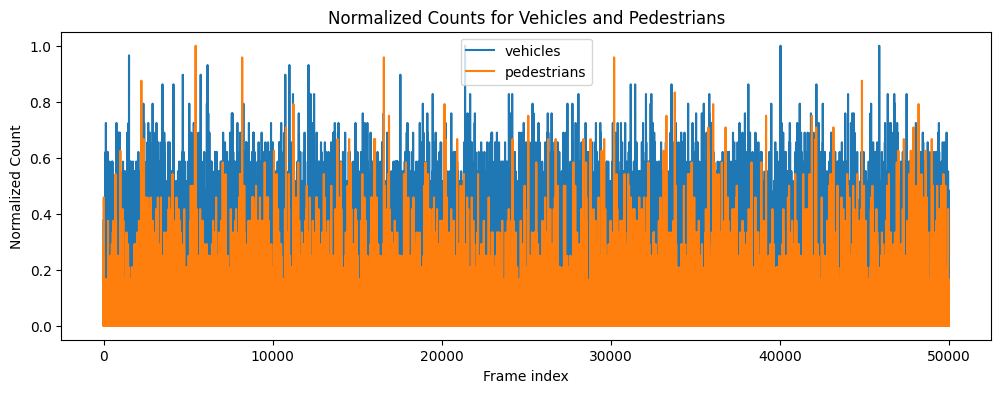

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Make sure columns are float (for scaling)
df['vehicles'] = df['vehicles'].astype(float)
df['pedestrians'] = df['pedestrians'].astype(float)

values = df[['vehicles', 'pedestrians']].values

# Normalize features to [0,1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# Visualize
plt.figure(figsize=(12, 4))
plt.plot(scaled[:,0], color='tab:blue', label="vehicles")
plt.plot(scaled[:,1], color='tab:orange', label="pedestrians")
plt.xlabel('Frame index')
plt.ylabel('Normalized Count')
plt.legend()
plt.title('Normalized Counts for Vehicles and Pedestrians')
plt.show()

## 3. Create Input Sequences for LSTM

- We'll use a typical sequence-to-one model: Use `window_size` frames to predict the next vehicle (or congestion) count.

In [ ]:
def create_sequences(data, window=10):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window, 0])  # Predict only 'vehicles' for now (index 0)
    return np.array(X), np.array(y)

WINDOW_SIZE = 100  # Try 10 as "lookback"; adjust/tune as you wish.

X, y = create_sequences(scaled, window=WINDOW_SIZE)
print("X shape:", X.shape, ", y shape:", y.shape)

X shape: (49900, 100, 2) , y shape: (49900,)


## 4. Train-Test Split

In [ ]:
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")

Train shape: (39920, 100, 2), (39920,)
Test shape: (9980, 100, 2), (9980,)


## 5. Build and Train the LSTM Model (TensorFlow/Keras)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, X.shape[2])),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # Forecast the vehicle count
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Train
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0200 - mae: 0.1114

KeyboardInterrupt: 

## 6. Evaluate Model Performance

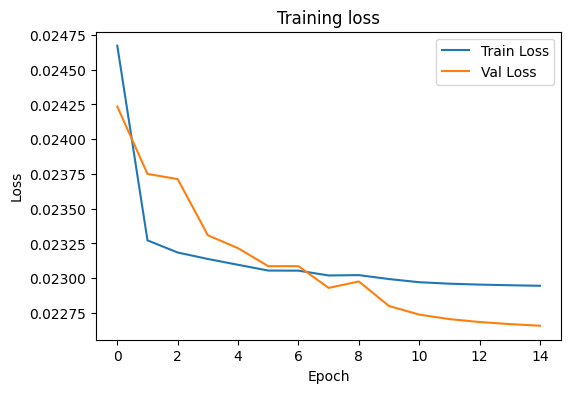

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 7. Evaluate: Prediction and Visualization

- Inverse transform to original scale
- Visualize prediction vs. actual

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


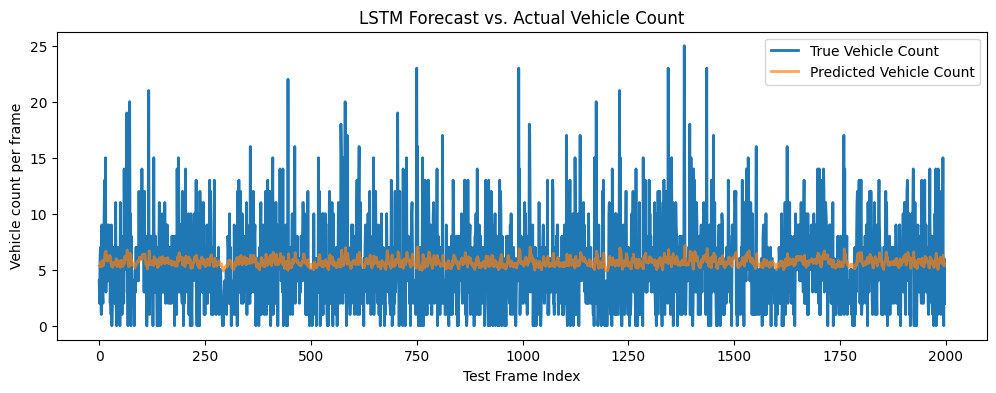

Test MAE: 3.14
Test R^2 : -0.01


In [ ]:
# Predict
y_pred = model.predict(X_test)

# Inverse scale prediction and truth (set "pedestrians" column to dummy zeros for inverse_transform)
n = y_test.shape[0]
y_test_inv = scaler.inverse_transform(np.hstack([y_test.reshape(-1,1), np.zeros((n,1))]))[:,0]
y_pred_inv = scaler.inverse_transform(np.hstack([y_pred, np.zeros((n,1))]))[:,0]

plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label='True Vehicle Count', lw=2)
plt.plot(y_pred_inv, label='Predicted Vehicle Count', lw=2, alpha=0.7)
plt.title('LSTM Forecast vs. Actual Vehicle Count')
plt.ylabel('Vehicle count per frame')
plt.xlabel('Test Frame Index')
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f"Test MAE: {mae:.2f}")
print(f"Test R^2 : {r2:.2f}")

## 8. Export the Predictions

For use by downstream modules (e.g., anomaly detection, RL for traffic light control).

In [ ]:
out_df = pd.DataFrame({
    "frame_idx": np.arange(len(y_test_inv)),
    "true_vehicles": y_test_inv,
    "predicted_vehicles": y_pred_inv
})
out_df.to_csv("lstm_predicted_vehicles.csv", index=False)
print("Saved: lstm_predicted_vehicles.csv")

Saved: lstm_predicted_vehicles.csv


## Discussion

- This model demonstrates how deep learning can predict future vehicle counts given recent traffic patterns.
- For further performance:
    - Tune window size, epochs, LSTM layers.
    - Add temporal/holiday/weekday features if known.
    - Predict both vehicles and pedestrians (make y a vector), or multi-step-ahead.
- Results are ready for anomaly detection, "what-if" scenario simulation, and dynamic traffic control.

---

#### References
- Hochreiter & Schmidhuber, LSTM, Neural Computation, 1997.
- Keras LSTM [docs](https://keras.io/api/layers/recurrent_layers/lstm/)

---

*End of Module 2*